# Will this Patient be Readmitted Within 30 Days?

**Input:**
- Discharge Summary
- Prior Readmissions
- Diagnosis

**Output:** Yes/No

## Possible Models:
- Logistic Regression
- Random Forest
- Gradient Boosted Trees

In [0]:
import numpy as np
import pandas as pd
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from pyspark.sql.functions import col, to_date, datediff, unix_timestamp, lead, when, year
from pyspark.sql.types import IntegerType
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from pyspark.sql import Window


# Get the Dataset from Databricks

In [0]:
# %sql
# use hive_metastore.silver

# table_names = [
#     "condition_",
#     "claim_",
#     "encounter_",
#     "observation_",
#     "organization_",
#     "procedure_",
#     "patient_",
# ]

# # Dictionary to store all DataFrames
# dataframes = {}

# for table_name in table_names:
#     spark_df = spark.sql(f"SELECT * FROM silver.{table_name}")
#     dataframes[table_name] = spark_df.toPandas()

# # Access DataFrames like: dataframes["condition_"], dataframes["patient_"], etc.

# Get the Dataset from csv

In [ ]:
# Load CSV files from the Data folder
import os

data_folder = "c:/Users/Nicholas/Documents/GitHub/PorfolioProjects/Synthea/Data/"
csv_files = {
    "condition_": "Synthetic ML Condition Data.csv",
    "claim_": "Synthetic ML Claim Data.csv",
    "encounter_": "Synthetic ML Encounter Data.csv",
    "observation_": "Synthetic ML Observation Data.csv",
    "organization_": "Synthetic ML Organization Data.csv",
    "procedure_": "Synthetic ML Procedure Data.csv",
    "patient_": "Synthetic ML Patient Data.csv",
}

# Dictionary to store all DataFrames
dataframes = {}

for table_name, file_name in csv_files.items():
    file_path = os.path.join(data_folder, file_name)
    dataframes[table_name] = pd.read_csv(file_path)

# Access DataFrames like: dataframes["condition_"], dataframes["patient_"], etc.

In [ ]:
# Convert Pandas DataFrames to Spark DataFrames
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Synthea").getOrCreate()

spark_dataframes = {table_name: spark.createDataFrame(df) for table_name, df in dataframes.items()}

# Example: Access Spark DataFrames like spark_dataframes["condition_"], spark_dataframes["patient_"], etc.

In [0]:
# Load the encounter_ and patient_ dataframes from the dictionary
encounter_pandas_df = dataframes["encounter_"]

# Convert the Pandas DataFrame to Spark DataFrame
encounter_spark_df = spark.createDataFrame(encounter_pandas_df)

# Convert ISO 8601 string to datetime using Spark functions
encounter_spark_df = (
    encounter_spark_df.withColumn("start_date", to_date(col("start_time")))
    .withColumn("end_date", to_date(col("end_time")))
    .withColumn("duration_days", datediff(col("end_date"), col("start_date")))
)

patient_df = dataframes["patient_"]
patient_df["first_name"] = patient_df["first_name"].str.replace(r"\d+", "", regex=True)
patient_df["last_name"] = patient_df["last_name"].str.replace(r"\d+", "", regex=True)

# Convert the Pandas DataFrame back to Spark DataFrame
patient_spark_df = spark.createDataFrame(patient_df)

patient_spark_df = patient_spark_df.withColumn("birth_date", to_date(col("birth_date")))

# Perform the left outer join
patient_encounters_df = encounter_spark_df.join(
    patient_spark_df, on="patient_id", how="left_outer"
)

# Display the result
display(patient_encounters_df)

patient_id,encounter_id,status,class_code,class_system,start_time,end_time,encounter_type_display,encounter_type_code,encounter_type_text,subject_display,subject_reference,practitioner_display,practitioner_reference,service_provider_name,service_provider_reference,run_id,source_file,start_date,end_date,duration_days,birth_date,gender,first_name,middle_name,last_name,prefix,city,state,zip,country,street,phone,phone_use,marital_status,language_code,synthea_id,run_id,source_file
57f64a10-d647-474b-9766-5a19e02b102a,a354b693-ac07-2f65-690d-8bb0c1cf6ab6,finished,AMB,http://terminology.hl7.org/CodeSystem/v3-ActCode,1975-09-23T13:26:12-04:00,1975-09-23T13:41:12-04:00,Encounter for problem (procedure),185347001,Encounter for problem (procedure),Mr. Bill567 Garfield38 Morissette863,urn:uuid:57f64a10-d647-474b-9766-5a19e02b102a,Dr. Carson894 Krajcik437,Practitioner?identifier=http://hl7.org/fhir/sid/us-npi|9999991695,FRANCISCAN HOSPITAL FOR CHILDREN INC,Organization?identifier=https://github.com/synthetichealth/synthea|c7542447-e06e-32cb-b6db-243c23a0dbc2,s212p10,dbfs:/mnt/synthea-analytics/runs/s212p10/raw/fhir/Bill567_Morissette863_57f64a10-d647-474b-9766-5a19e02b102a.json,1975-09-23,1975-09-23,0,1974-06-08,male,Bill,Garfield38,Morissette,Mr.,Newton,MA,02462,US,289 Buckridge Bay,555-903-7254,home,Married,en-US,57f64a10-d647-474b-9766-5a19e02b102a,s212p10,dbfs:/mnt/synthea-analytics/runs/s212p10/raw/fhir/Bill567_Morissette863_57f64a10-d647-474b-9766-5a19e02b102a.json
57f64a10-d647-474b-9766-5a19e02b102a,7e8b5715-ee51-9cb0-f0eb-f5a2cd850d9f,finished,AMB,http://terminology.hl7.org/CodeSystem/v3-ActCode,1975-10-09T12:26:12-04:00,1975-10-09T12:54:02-04:00,Encounter for problem (procedure),185347001,Encounter for problem (procedure),Mr. Bill567 Garfield38 Morissette863,urn:uuid:57f64a10-d647-474b-9766-5a19e02b102a,Dr. Carson894 Krajcik437,Practitioner?identifier=http://hl7.org/fhir/sid/us-npi|9999991695,FRANCISCAN HOSPITAL FOR CHILDREN INC,Organization?identifier=https://github.com/synthetichealth/synthea|c7542447-e06e-32cb-b6db-243c23a0dbc2,s212p10,dbfs:/mnt/synthea-analytics/runs/s212p10/raw/fhir/Bill567_Morissette863_57f64a10-d647-474b-9766-5a19e02b102a.json,1975-10-09,1975-10-09,0,1974-06-08,male,Bill,Garfield38,Morissette,Mr.,Newton,MA,02462,US,289 Buckridge Bay,555-903-7254,home,Married,en-US,57f64a10-d647-474b-9766-5a19e02b102a,s212p10,dbfs:/mnt/synthea-analytics/runs/s212p10/raw/fhir/Bill567_Morissette863_57f64a10-d647-474b-9766-5a19e02b102a.json
57f64a10-d647-474b-9766-5a19e02b102a,3ce9d2a8-cf3c-3eb1-f81b-7efd61921964,finished,AMB,http://terminology.hl7.org/CodeSystem/v3-ActCode,1992-08-01T09:26:12-04:00,1992-08-01T10:03:10-04:00,General examination of patient (procedure),162673000,General examination of patient (procedure),Mr. Bill567 Garfield38 Morissette863,urn:uuid:57f64a10-d647-474b-9766-5a19e02b102a,Dr. Alonso270 Hand679,Practitioner?identifier=http://hl7.org/fhir/sid/us-npi|9999968297,PERSONAL PHYSICIANS HEALTHCARE PC,Organization?identifier=https://github.com/synthetichealth/synthea|65eda534-1bdc-3192-8d02-1c3764447790,s212p10,dbfs:/mnt/synthea-analytics/runs/s212p10/raw/fhir/Bill567_Morissette863_57f64a10-d647-474b-9766-5a19e02b102a.json,1992-08-01,1992-08-01,0,1974-06-08,male,Bill,Garfield38,Morissette,Mr.,Newton,MA,02462,US,289 Buckridge Bay,555-903-7254,home,Married,en-US,57f64a10-d647-474b-9766-5a19e02b102a,s212p10,dbfs:/mnt/synthea-analytics/runs/s212p10/raw/fhir/Bill567_Morissette863_57f64a10-d647-474b-9766-5a19e02b102a.json
57f64a10-d647-474b-9766-5a19e02b102a,1081fcfc-5d01-0db4-a4e3-517f4f6a5be2,finished,EMER,http://terminology.hl7.org/CodeSystem/v3-ActCode,1993-05-20T09:26:12-04:00,1993-05-20T10:26:12-04:00,Emergency treatment (procedure),182813001,Emergency treatment (procedure),Mr. Bill567 Garfield38 Morissette863,urn:uuid:57f64a10-d647-474b-9766-5a19e02b102a,Dr. Lanette41 Murray856,Practitioner?identifier=http://hl7.org/fhir/sid/us-npi|9999889790,STONEHEDGE HEALTH CARE CENTER,Organization?identifier=https://git

In [0]:
# """
# This takes care of patient conditions. We can see what conditions they have, the date of onset and recorded date, and we have details about the patient.
# """

# # Load the encounter_ and patient_ dataframes from the dictionary
# condition_df_df = dataframes["condition_"]
# patient_df = dataframes["patient_"]
# patient_df["first_name"] = patient_df["first_name"].str.replace(r"\d+", "", regex=True)
# patient_df["last_name"] = patient_df["last_name"].str.replace(r"\d+", "", regex=True)

# # Convert the Pandas DataFrames back to Spark DataFrames
# encounter_spark_df = spark.createDataFrame(condition_df_df)
# patient_spark_df = spark.createDataFrame(patient_df)

# # Perform the left outer join
# patient_conditions_df = encounter_spark_df.join(
#     patient_spark_df, on="patient_id", how="left_outer"
# )

# # Display the result
# # display(patient_conditions_df)

In [0]:
# Count the number of encounters per patient
encounter_count_df = patient_encounters_df.groupBy(
    "patient_id", "first_name", "last_name"
).count()
display(encounter_count_df)

patient_id,first_name,last_name,count
57f64a10-d647-474b-9766-5a19e02b102a,Bill,Morissette,44
4f648f81-8c7a-bb0a-16f8-744c028fc9fd,Cory,Mayert,69
b0aa9e58-e54c-0082-0c17-82c84788d5ec,Ernest,Jast,567
02c9b909-e1a3-7f91-6e8a-5c55a25d45f6,Sandy,O'Reilly,30
562a37a6-b0e0-501e-8912-63ccba146eb0,Lawerence,O'Kon,68
d5631662-a8c1-49ee-df45-5251a41117f0,Noel,Boyle,30
8174bbcc-4b8c-d8fa-3488-2bea2fae12a0,Juana,Dach,32
f6ae995b-a00d-749b-ef2b-1881ab8b26c6,Janeen,Luettgen,61
993fb8ba-c9a8-029f-db12-85574a42b7d8,Waylon,Olson,30
382b52df-9bcf-c0b9-28db-4b4f79172394,Kazuko,Hackett,34


In [0]:
# Sort by patient_id and start_time using a window
w = Window.partitionBy("patient_id").orderBy("start_time")

# Add next encounter's start_time
df_sorted = patient_encounters_df.withColumn(
    "next_start_time", lead("start_time").over(w)
)

# Calculate days until next encounter
df_sorted = df_sorted.withColumn(
    "days_until_next", datediff(col("next_start_time"), col("end_time"))
)

# Create readmission label: 1 if within 30 days, 0 otherwise
df_sorted = df_sorted.withColumn(
    "readmitted_within_30_days",
    when((col("days_until_next") >= 0) & (col("days_until_next") <= 30), 1).otherwise(
        0
    ),
)

# Optional: check distribution
df_sorted.groupBy("readmitted_within_30_days").count().show()

+-------------------------+-----+
|readmitted_within_30_days|count|
+-------------------------+-----+
|                        1|  739|
|                        0|  256|
+-------------------------+-----+



# Feature and Target Selection

In [0]:
# Calculate age: year(start_time) - year(birth_date)
df_clean = df_sorted.withColumn("age", year("start_time") - year("birth_date"))

# Define feature columns again
features_to_keep = [
    "status",
    "encounter_type_code",
    "encounter_type_text",
    "duration_days",
    "gender",
    "marital_status",
    "age",
]

# Define target column
target_col = "readmitted_within_30_days"

# Select relevant columns from the PySpark DataFrame
selected_cols = features_to_keep + [target_col]
df_pandas = df_clean.select(*selected_cols).toPandas()

# Drop rows with missing values
df_pandas = df_pandas.dropna()

# Split into features (X) and target (y)
X = df_pandas[features_to_keep]
y = df_pandas[target_col]

# Preprocessing

In [0]:
# Define categorical and numeric columns
categorical_features = ["status", "encounter_type_text", "gender", "marital_status"]
numeric_features = ["encounter_type_code", "duration_days", "age"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="mean")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
    ]
)

# Now X and y are ready to be used in a model pipeline

# Modeling

In [0]:
# set the experiment id
mlflow.set_experiment(experiment_id="336962172052827")

mlflow.autolog()

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Full modeling pipeline ---
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs")),
    ]
)

# --- Train the model ---
model.fit(X_train, y_train)

# --- Evaluate ---
# By default, models predict Class 1 if the probability is greater than or equal to 0.5.

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

2025/05/27 17:28:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/05/27 17:28:04 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2025/05/27 17:28:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.
2025/05/27 17:28:04 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.ml.
2025/05/27 17:28:05 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '699c4dc87be549d7b4f732b0ebd9ac92', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/05/27 17:28:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.11/site-packages/mlflow/types/utils.py:393: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent m

              precision    recall  f1-score   support

           0       0.56      0.55      0.55        51
           1       0.85      0.85      0.85       148

    accuracy                           0.77       199
   macro avg       0.70      0.70      0.70       199
weighted avg       0.77      0.77      0.77       199



# calibration

2025/05/27 17:28:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.11/site-packages/mlflow/types/utils.py:393: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
/databricks/python/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set t

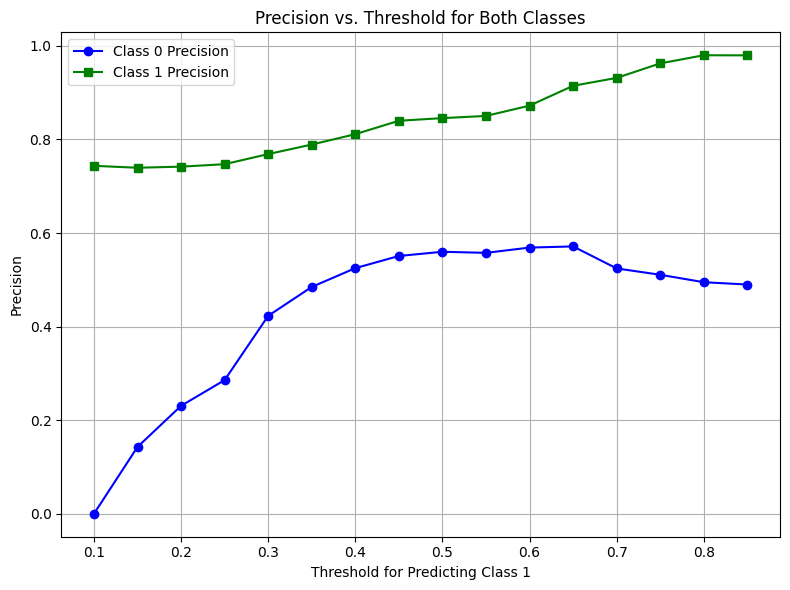

In [0]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score


# Get probabilities for the positive class (Class 1)
y_probs = model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
prec_class_0 = []
prec_class_1 = []

# Compute precision for both classes at different thresholds
for t in thresholds:
    y_pred_thresh = (y_probs >= t).astype(int)
    prec_class_0.append(precision_score(y_test, y_pred_thresh, pos_label=0))
    prec_class_1.append(precision_score(y_test, y_pred_thresh, pos_label=1))

# Plot both
plt.figure(figsize=(8, 6))
plt.plot(thresholds, prec_class_0, marker='o', label='Class 0 Precision', color='blue')
plt.plot(thresholds, prec_class_1, marker='s', label='Class 1 Precision', color='green')
plt.xlabel("Threshold for Predicting Class 1")
plt.ylabel("Precision")
plt.title("Precision vs. Threshold for Both Classes")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Second Run
0.5714285714285714: Class 0 Precision (This is the most precision you get)
0.9147286821705426: Class 1 Precision (This is the precision you get when class 0 is at its most precise)
Threshold at these points: 0.65

In [0]:
# Set the experiment id
mlflow.set_experiment(experiment_id="336962172052827")

mlflow.autolog()

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Full modeling pipeline ---
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs")),
    ]
)

# --- Train the model ---
model.fit(X_train, y_train)

# --- Evaluate with specified threshold ---
y_probs = model.predict_proba(X_test)[:, 1]
threshold = 0.65
y_pred_thresh = (y_probs >= threshold).astype(int)

print(classification_report(y_test, y_pred_thresh))

2025/05/27 17:28:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/05/27 17:28:15 WARNING mlflow.spark: With Pyspark >= 3.2, PYSPARK_PIN_THREAD environment variable must be set to false for Spark datasource autologging to work.
2025/05/27 17:28:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.
2025/05/27 17:28:15 INFO mlflow.tracking.fluent: Autologging successfully enabled for pyspark.ml.
2025/05/27 17:28:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '9687fc6895824c519e1399b329362588', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2025/05/27 17:28:17 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/databricks/python/lib/python3.11/site-packages/mlflow/types/utils.py:393: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent m

              precision    recall  f1-score   support

           0       0.57      0.78      0.66        51
           1       0.91      0.80      0.85       148

    accuracy                           0.79       199
   macro avg       0.74      0.79      0.76       199
weighted avg       0.83      0.79      0.80       199

